## Import Required Libraries

In [15]:
import pandas as pd
import numpy as np

# machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [2]:
# Load dataset
data = pd.read_csv("traffic.csv")

# Preview data
print(data.head())

              DateTime  Junction  Vehicles           ID
0  2015-11-01 00:00:00         1        15  20151101001
1  2015-11-01 01:00:00         1        13  20151101011
2  2015-11-01 02:00:00         1        10  20151101021
3  2015-11-01 03:00:00         1         7  20151101031
4  2015-11-01 04:00:00         1         9  20151101041


## Convert DateTime to Useful Features

In [4]:
# Convert DateTime column to datetime format
data["DateTime"] = pd.to_datetime(data["DateTime"])

# Extract useful features
data["hour"] = data["DateTime"].dt.hour
data["day"] = data["DateTime"].dt.day
data["month"] = data["DateTime"].dt.month
data["weekday"] = data["DateTime"].dt.weekday

# Weekend indicator
data["is_weekend"] = data["weekday"].apply(lambda x: 1 if x >= 5 else 0)
print(data.head())

             DateTime  Junction  Vehicles           ID  hour  day  month  \
0 2015-11-01 00:00:00         1        15  20151101001     0    1     11   
1 2015-11-01 01:00:00         1        13  20151101011     1    1     11   
2 2015-11-01 02:00:00         1        10  20151101021     2    1     11   
3 2015-11-01 03:00:00         1         7  20151101031     3    1     11   
4 2015-11-01 04:00:00         1         9  20151101041     4    1     11   

   weekday  is_weekend  
0        6           1  
1        6           1  
2        6           1  
3        6           1  
4        6           1  


## Define Features and Target

In [5]:
features = [
    "Junction",
    "hour",
    "day",
    "month",
    "weekday",
    "is_weekend"
]

X = data[features]
y = data["Vehicles"]

## Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Train Random Forest Model

In [8]:
# Create Random Forest model
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

## Make Predictions

In [9]:
# Predict traffic on test data
predictions = model.predict(X_test)

print(predictions[:10])

[ 9.08002063 27.73285471  6.62174814  9.26987905 20.45200247 16.90614356
  8.48829544 14.17835673 14.32031288 24.95826719]


## Evaluate Model

In [10]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 6.888058011282626
RMSE: 10.065165706858783
R2 Score: 0.7514210033253148


## Predict Traffic for a Specific Time

In [11]:
# Example input
sample = pd.DataFrame({
    "Junction": [2],
    "hour": [8],
    "day": [15],
    "month": [11],
    "weekday": [0],
    "is_weekend": [0]
})

prediction = model.predict(sample)

print("Predicted Vehicles:", prediction[0])

Predicted Vehicles: 9.960506779421053


## Convert Prediction to Congestion Level

In [12]:
def congestion_level(vehicles):

    if vehicles < 20:
        return "Low"

    elif vehicles < 60:
        return "Medium"

    else:
        return "High"


level = congestion_level(prediction[0])

print("Traffic Level:", level)

Traffic Level: Low


## Traffic Volume Over Time

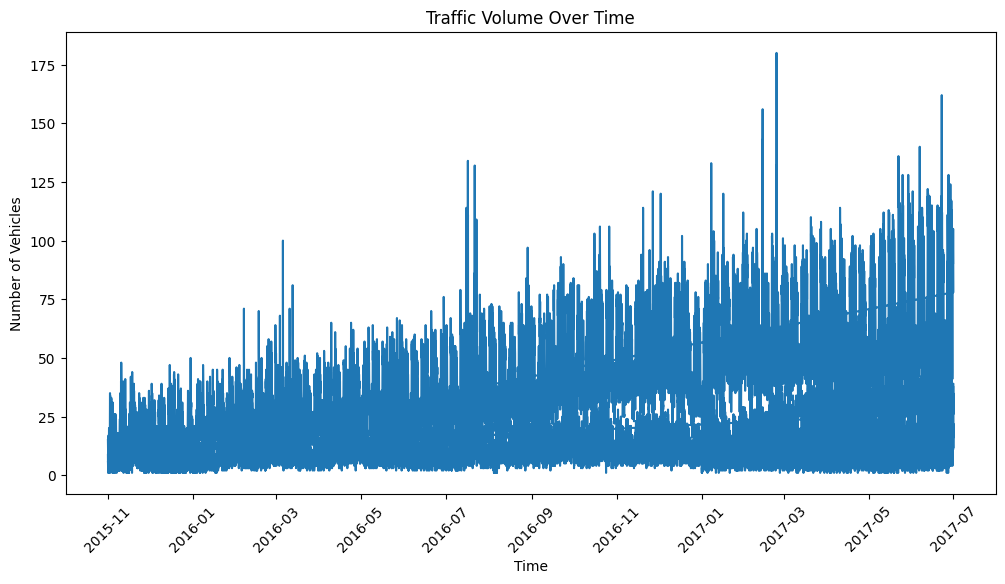

In [16]:
plt.figure(figsize=(12,6))

plt.plot(data["DateTime"], data["Vehicles"])

plt.xlabel("Time")
plt.ylabel("Number of Vehicles")
plt.title("Traffic Volume Over Time")

plt.xticks(rotation=45)

plt.show()

## Average Traffic by Hour (Very Important Graph)

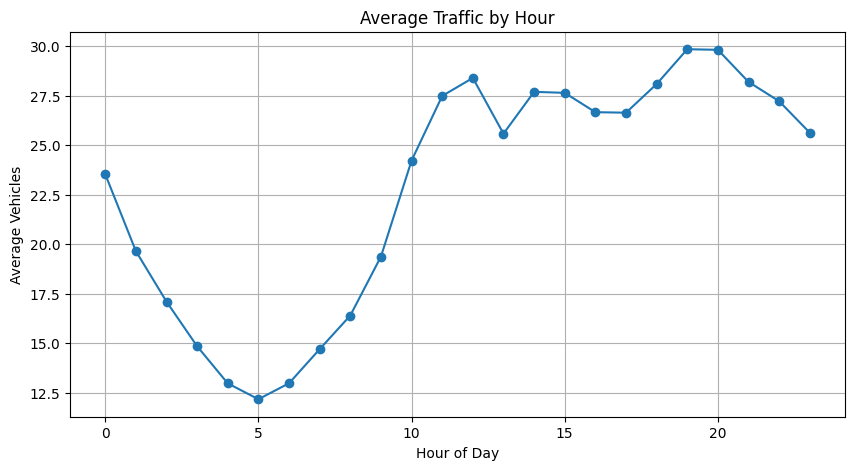

In [17]:
hourly_traffic = data.groupby("hour")["Vehicles"].mean()

plt.figure(figsize=(10,5))

plt.plot(hourly_traffic.index, hourly_traffic.values, marker='o')

plt.xlabel("Hour of Day")
plt.ylabel("Average Vehicles")
plt.title("Average Traffic by Hour")

plt.grid(True)

plt.show()

## Traffic by Weekday

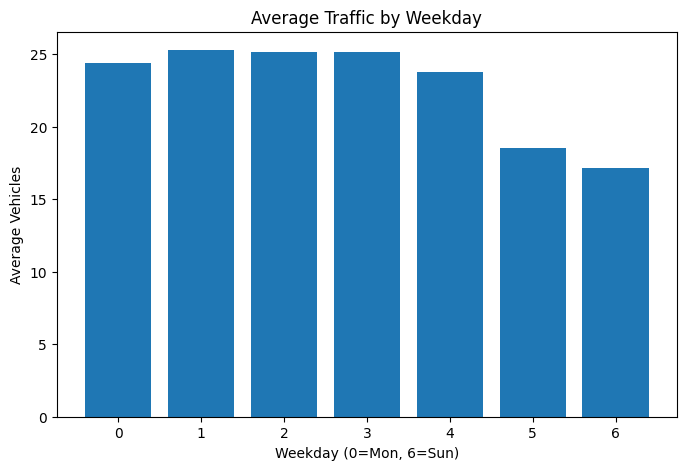

In [18]:
weekday_traffic = data.groupby("weekday")["Vehicles"].mean()

plt.figure(figsize=(8,5))

plt.bar(weekday_traffic.index, weekday_traffic.values)

plt.xlabel("Weekday (0=Mon, 6=Sun)")
plt.ylabel("Average Vehicles")
plt.title("Average Traffic by Weekday")

plt.show()

## Traffic Distribution (Histogram)
Shows how traffic values are distributed.

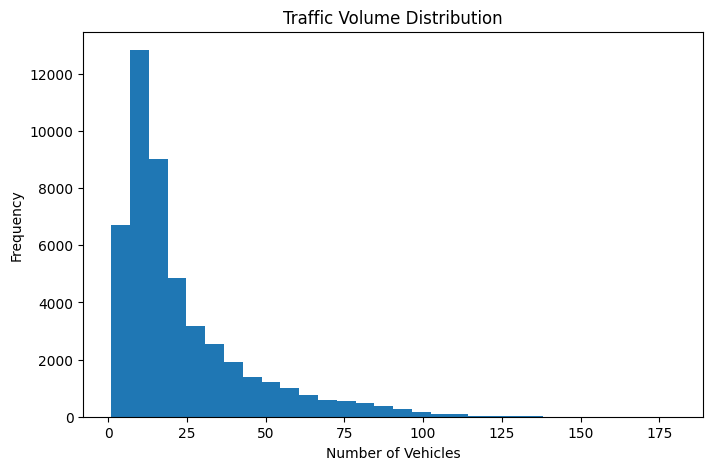

In [19]:
plt.figure(figsize=(8,5))

plt.hist(data["Vehicles"], bins=30)

plt.xlabel("Number of Vehicles")
plt.ylabel("Frequency")
plt.title("Traffic Volume Distribution")

plt.show()

## Traffic by Junction (Very Useful)

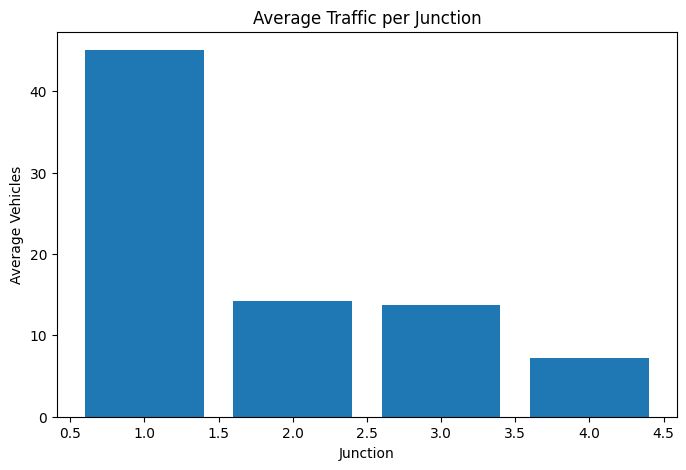

In [20]:
junction_traffic = data.groupby("Junction")["Vehicles"].mean()

plt.figure(figsize=(8,5))

plt.bar(junction_traffic.index, junction_traffic.values)

plt.xlabel("Junction")
plt.ylabel("Average Vehicles")
plt.title("Average Traffic per Junction")

plt.show()

## Heatmap of Traffic by Hour and Weekday 

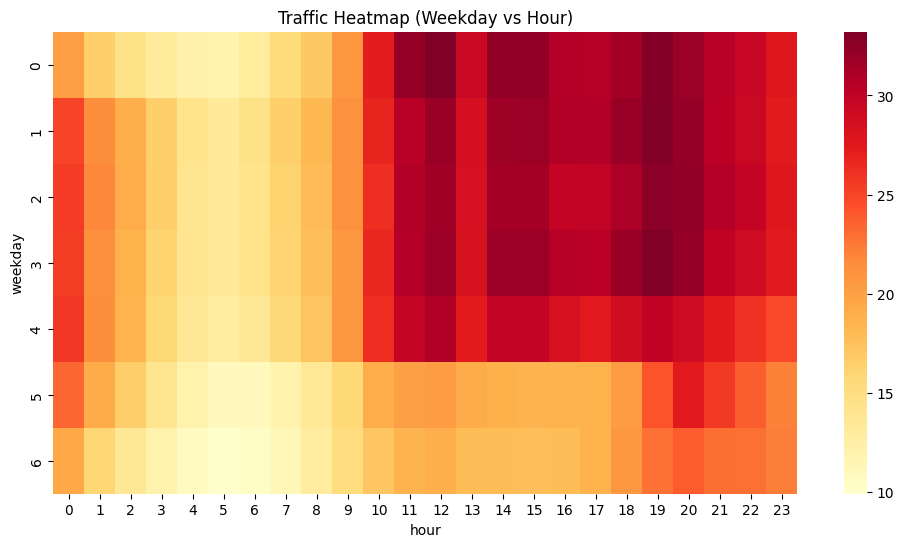

In [21]:
pivot = data.pivot_table(
    values="Vehicles",
    index="weekday",
    columns="hour",
    aggfunc="mean"
)

plt.figure(figsize=(12,6))

sns.heatmap(pivot, cmap="YlOrRd")

plt.title("Traffic Heatmap (Weekday vs Hour)")

plt.show()